## Plotting summary statistics about the annotated SNPs

In [1]:
import pandas as pd

In [4]:
full_collapse_rsid = pd.read_excel("full_collapse_rsid_annotations.xlsx")
full_collapse_rsid.iloc[0:2,]

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,...,GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_distFtpts,ME_distTSS,ME_PredTargets,CHMM_Variants,CHMM_Labels,CHMM_Tissues
0,2.0,62292158.0,62294394.0,chr2:62292365;chr2:62293877,Intergenic;Intergenic,62293629.0,rs72803385,0.9375,1.0430,0.037640,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,02_62293629_C_T,BivFlnk;Enh;EnhBiv;TssAFlnk,"Liver;Adipose,Blood,Brain,Digestive,ES-deriv,E..."
1,17.0,9556759.0,9558036.0,chr17:9557459,Exon,9557841.0,rs34354226,0.9209,0.9649,0.001963,...,NaN,17_9557841_T_C,intron_variant,VEP,0,-17979,STX8,17_9557841_T_C;17_9557841_T_G,Enh;EnhG,"Bone,Digestive,Liver,Mesench;Heart"


In [52]:
testing = full_collapse_rsid.loc[full_collapse_rsid["CHR"]==6,]
testing = testing.loc[testing["BP"] > 30743024,]
testing = testing.loc[testing["BP"] < 30813523,]
testing[["central", 'note', 'BP', 'rsid', 'OR_copd', 'OR_asthma', 'P_copd', 'P_asthma', 'meta_p_weighted']]

,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,P_asthma,meta_p_weighted
115,chr6:30759272;chr6:30759890,Intergenic;Intergenic,30759162.0,rs3095340,1.0270,1.0320,0.3181,0.02377,0.039382
196,chr6:30781592,Intron,30781456.0,rs9468829,1.0180,1.0280,0.4929,0.04077,0.102057
713,chr6:30749136;chr6:30752568,Intergenic;Intergenic,30752534.0,rs28780111,1.0090,0.9756,0.7239,0.05704,0.232833
787,chr6:30759272;chr6:30759890,Intergenic;Intergenic,30759505.0,rs3869075,1.0110,0.9770,0.6653,0.07318,0.225634
828,chr6:30764445,Intergenic,30763728.0,rs13214831,1.0110,0.9776,0.6416,0.08022,0.222902
868,chr6:30749136;chr6:30752568,Intergenic;Intergenic,30750403.0,rs2535323,1.0110,0.9781,0.6640,0.08545,0.243306
910,chr6:30759272;chr6:30759890,Intergenic;Intergenic,30760583.0,rs3094122,1.0020,1.0220,0.9408,0.09417,0.551953
1566,chr6:30769589,Intron,30770631.0,rs3094116,1.0200,1.0140,0.3583,0.21950,0.208997
1736,chr6:30759272;chr6:30759890,Intergenic;Intergenic,30760513.0,rs3131036,1.0160,1.0130,0.4559,0.24710,0.284259
1788,chr6:30749136;chr6:30752568,Intergenic;Intergenic,30750258.0,rs2535324,1.0110,0.9879,0.6095,0.25580,0.389151


In [5]:
print(full_collapse_rsid.columns)

Index(['CHR', 'start', 'stop', 'central', 'note', 'BP', 'rsid', 'OR_copd',
       'OR_asthma', 'P_copd', 'P_asthma', 'meta_p_weighted', 'same_direction',
       'Asthma', 'COPD', 'Asthma OR COPD', 'Asthma AND COPD',
       'UPM30_L2FC(padj)', 'UPM120_L2FC(padj)', 'WSP30_L2FC(padj)',
       'WSP120_L2FC(padj)', 'Distance_to_Mu', 'TFBS_Variants', 'TFBS_TFs',
       'TFBS_CellTypes', 'TFBS_Tissues', 'DA_Variants', 'DA_Traits',
       'DA_Betas', 'DA_PostProbs', 'DA_Assoc_types', 'DA_PredTargets',
       'DA_PTScores', 'DA_LocusSizes', 'DA_Same_variants', 'DA_Sources',
       'GT_Variants', 'GTs', 'GTs_Sources', 'GTs_Tissues', 'GTs_Same_Variants',
       'GTs_Betas', 'GTs_PostProbs', 'GTs_Pvalues', 'GTs_UPM30_L2FC(padj)',
       'GTs_UPM120_L2FC(padj)', 'GTs_WSP30_L2FC(padj)',
       'GTs_WSP120_L2FC(padj)', 'ME_Variants', 'ME_EffectPreds',
       'ME_EffectMeths', 'ME_distFtpts', 'ME_distTSS', 'ME_PredTargets',
       'CHMM_Variants', 'CHMM_Labels', 'CHMM_Tissues'],
      dtype='object')


## Get some summary stats
- Number/percentage of variants that:
	- Same direction for Asthma and COPD
	- Both significant for Asthma and COPD
	- Both significant AND same direction for Asthma and COPD
	- TFBS sites in lung (or any)
	- Associated with other diseases/traits

In [6]:
# Get the conditions of interest

full_conditions = {
  	"Other Trait-associated": full_collapse_rsid["DA_Variants"].notna(),
    "ENCODE TF\nBinding Site": full_collapse_rsid["TFBS_Variants"].notna(),
    "One significant": ((full_collapse_rsid["Asthma OR COPD"] == 1)),
    "Both significant\n+ same direction": ((full_collapse_rsid["Asthma AND COPD"] == 1) & 
                                          (full_collapse_rsid["same_direction"] == "Yes")),
    "Both significant": ((full_collapse_rsid["Asthma AND COPD"] == 1)),
    "Same direction": (full_collapse_rsid["same_direction"] == "Yes")
       
}

# --- Step 2: Build summary table ---
full_summary = pd.DataFrame([
    {"Category": name,
     "Count": cond.sum(),
     "Percentage": cond.mean() * 100}
    for name, cond in full_conditions.items()
])
full_summary


,Category,Count,Percentage
0,Other Trait-associated,44,0.654081
1,ENCODE TF\nBinding Site,398,5.916456
2,One significant,681,10.123383
3,Both significant\n+ same direction,15,0.222982
4,Both significant,18,0.267578
5,Same direction,3144,46.737030


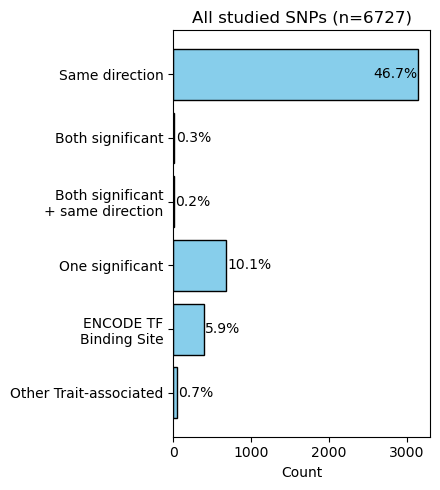

In [7]:
import matplotlib.pyplot as plt
fig, ax1 = plt.subplots(figsize=(4.5, 5))


bars = ax1.barh(full_summary["Category"], full_summary["Count"], color="skyblue", edgecolor="black")
ax1.set_xlabel("Count")
ax1.set_ylabel("")

# Add percentages at the end of bars
for bar, perc in zip(bars, full_summary["Percentage"]):
    if perc > 20:
        ax1.text(bar.get_width() - 8, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", ha="right", color="black", fontsize=10)
    else:
        ax1.text(bar.get_width() + 17, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", fontsize=10)
plt.title(f"All studied SNPs (n={full_collapse_rsid.shape[0]})")
plt.tight_layout()



### Only considering those significant in at least one direction

In [8]:
onesig_collapse_rsid = full_collapse_rsid[full_collapse_rsid["Asthma OR COPD"] == 1]

# Get the conditions of interest
conditions = {
  	"Other Trait-associated": onesig_collapse_rsid["DA_Variants"].notna(),
    "ENCODE TF\nBinding Site": onesig_collapse_rsid["TFBS_Variants"].notna(),
    "Both significant\n+ same direction": ((onesig_collapse_rsid["Asthma AND COPD"] == 1) & 
                                          (onesig_collapse_rsid["same_direction"] == "Yes")),
    "Both significant": ((onesig_collapse_rsid["Asthma AND COPD"] == 1)),
    "Same direction": (onesig_collapse_rsid["same_direction"] == "Yes")
    
    
}

# --- Step 2: Build summary table ---
summary = pd.DataFrame([
    {"Category": name,
     "Count": cond.sum(),
     "Percentage": cond.mean() * 100}
    for name, cond in conditions.items()
])
summary


,Category,Count,Percentage
0,Other Trait-associated,44,6.461087
1,ENCODE TF\nBinding Site,398,58.443465
2,Both significant\n+ same direction,15,2.202643
3,Both significant,18,2.643172
4,Same direction,389,57.121880


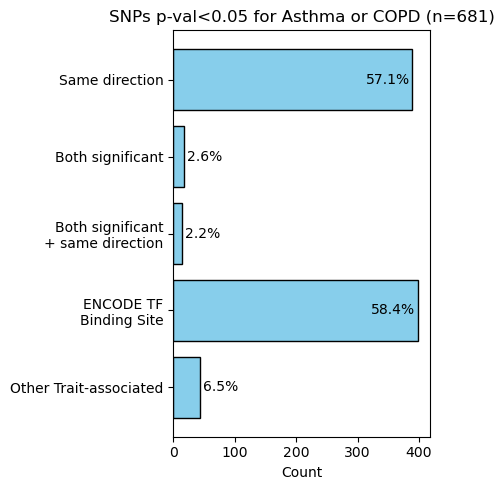

In [9]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(4.5, 5))

bars = ax.barh(summary["Category"], summary["Count"], color="skyblue", edgecolor="black")
ax.set_xlabel("Count")
ax.set_ylabel("")

# Add percentages at the end of bars
for bar, perc in zip(bars, summary["Percentage"]):
    if perc > 20:
        ax.text(bar.get_width() - 4, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", ha="right", color="black", fontsize=10)
    else:
        ax.text(bar.get_width() + 4, bar.get_y() + bar.get_height()/2,
				f"{perc:.1f}%", va="center", fontsize=10)
plt.title(f"SNPs p-val<0.05 for Asthma or COPD (n={onesig_collapse_rsid.shape[0]})")
plt.tight_layout()
plt.show()

In [ ]:
# SNPs with association with lung related factors
mask = onesig_collapse_rsid["DA_Traits"].astype(str).str.contains(r"FEV|lung|LUNG|smok|chronic obstructive", case=False, na=False)
filtered_df = onesig_collapse_rsid[mask]

filtered_df

,CHR,start,stop,central,note,BP,rsid,OR_copd,OR_asthma,P_copd,...,GTs_WSP120_L2FC(padj),ME_Variants,ME_EffectPreds,ME_EffectMeths,ME_distFtpts,ME_distTSS,ME_PredTargets,CHMM_Variants,CHMM_Labels,CHMM_Tissues
122,19.0,55368493.0,55370326.0,chr19:55369334;chr19:55369987,LIET Gene TSS Intron;LIET Gene TSS Intergenic,55368504.0,rs1126757,0.9675,0.9772,0.093720,...,NaN,19_55368504_C_T,synonymous_variant,VEP,0,-1959,IL11,19_55368504_C_A;19_55368504_C_G;19_55368504_C_T,Enh;EnhBiv;EnhG;TssA;TssAFlnk,"ESC,Epithelial,Muscle,iPSC;Digestive,ESC,Muscl..."
321,10.0,49538531.0,49539588.0,chr10:49538818;chr10:49539121;chr10:49539121;c...,LIET Gene TSS Intergenic;Gene TSS Bid;Gene TSS...,49539493.0,rs3793784,0.9503,0.9867,0.015920,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10_49539493_G_C,BivFlnk;TssA;TssAFlnk;TssBiv,"ESC,Liver,iPSC;Blood,Brain,Digestive,ES-deriv,..."
519,14.0,93035018.0,93038064.0,chr14:93036010;chr14:93036974,LIET Gene TSS Intron;Gene TSS Bid,93037041.0,rs12894780,1.0600,0.9953,0.005961,...,NaN,14_93037041_T_C,intron_variant,VEP,0,-78884,ITPK1,14_93037041_T_C,Enh;EnhG;TssAFlnk,"Blood,Bone,Brain,Digestive,ES-deriv,ESC,Epithe..."


In [19]:
# Only consider if the same variant
onesig_collapse_rsid.loc["DA_Traits"] = onesig_collapse_rsid["DA_Traits"].str.replace(",", "-", regex=False)
# Step 1: split by ";" into lists
df_expanded = onesig_collapse_rsid.assign(
    DA_Traits=onesig_collapse_rsid["DA_Traits"].str.split(";"),
    DA_Variants=onesig_collapse_rsid["DA_Variants"].str.split(";")
)

df_expanded = df_expanded.dropna(subset=["DA_Traits"])[["DA_Traits", "DA_Variants", "BP", "OR_copd", "OR_asthma", "meta_p_weighted"]]

print(df_expanded.iloc[0:2,])
# Filter DA_Traits based on matching DA_Variants
def filter_traits(row):
    traits, variants, bp = row["DA_Traits"], row["DA_Variants"], str(int(row["BP"]))
    filtered = [
        trait for trait, var in zip(traits, variants) if f"_{bp}_" in var
    ]
    return filtered

df_expanded["Filtered_Traits"] = df_expanded.apply(filter_traits, axis=1)
print(df_expanded.iloc[0:2,])

# Keep only rows where there is at least one match
df_filtered = df_expanded[df_expanded["Filtered_Traits"].str.len() > 0]


# Step 5: count traits
trait_counts = df_filtered["Filtered_Traits"].value_counts()
trait_counts

                            DA_Traits        DA_Variants          BP  OR_copd  \
3                   [brain attribute]  [10_70662368_G_A]  70673381.0   0.9530   
8  [alkaline phosphatase measurement]  [12_52873837_G_A]  52873837.0   0.9454   

   OR_asthma  meta_p_weighted  
3     0.9742         0.000889  
8     0.9756         0.001011  
                            DA_Traits        DA_Variants          BP  OR_copd  \
3                   [brain attribute]  [10_70662368_G_A]  70673381.0   0.9530   
8  [alkaline phosphatase measurement]  [12_52873837_G_A]  52873837.0   0.9454   

   OR_asthma  meta_p_weighted                     Filtered_Traits  
3     0.9742         0.000889                                  []  
8     0.9756         0.001011  [alkaline phosphatase measurement]  


[serum albumin amount]                                                                       2
[prostate specific antigen amount]                                                           2
[erythrocyte volume]                                                                         2
[alkaline phosphatase measurement]                                                           1
[systolic blood pressure]                                                                    1
[glomerular filtration rate]                                                                 1
[protein measurement]                                                                        1
[schizophrenia]                                                                              1
[Hyper-IgM syndrome type 3, multiple sclerosis, mucocutaneous lymph node syndrome]           1
[apolipoprotein B measurement]                                                               1
[urate measurement]                               

In [21]:
df_filtered

,DA_Traits,DA_Variants,BP,OR_copd,OR_asthma,meta_p_weighted,Filtered_Traits
8,[alkaline phosphatase measurement],[12_52873837_G_A],52873837.0,0.9454,0.9756,0.001011,[alkaline phosphatase measurement]
11,"[Ellis-van Creveld syndrome (EVC), Ellis-van C...",[04_5753797_G_A],5753797.0,1.1280,1.0460,0.000267,[Ellis-van Creveld syndrome (EVC)]
20,"[neutrophil measurement-response to water, neu...","[10_3097348_A_G, 10_3095817_C_T, 10_3096285_G_T]",3095817.0,1.0060,1.0360,0.041602,[neutrophil measurement]
31,"[neutrophil measurement-response to water, neu...","[10_3097348_A_G, 10_3095253_G_A, 10_3095817_C_...",3095253.0,1.0090,1.0320,0.053423,[neutrophil measurement-response to vaccine]
40,[lymphocyte count],[14_103561933_T_C],103561933.0,1.0260,1.0330,0.010833,[lymphocyte count]
64,[prostate specific antigen amount],[17_2396472_A_G],2396472.0,1.0370,1.0310,0.007429,[prostate specific antigen amount]
69,[appendicular lean mass],[22_46079998_G_A],46079998.0,1.0070,1.0290,0.127221,[appendicular lean mass]
101,[erythrocyte count],[22_50578653_T_A],50578653.0,1.0090,0.9754,0.118957,[erythrocyte count]
122,"[smoking initiation, smoking status measurement]",[19_55368504_C_T],55368504.0,0.9675,0.9772,0.010090,[smoking initiation]
133,"[Peutz-Jeghers syndrome (PJS), Hereditary canc...","[19_1207239_G_A, 19_1207239_G_C, 19_1207239_G_T]",1207239.0,1.0140,1.0270,0.095215,"[Peutz-Jeghers syndrome (PJS), Hereditary canc..."


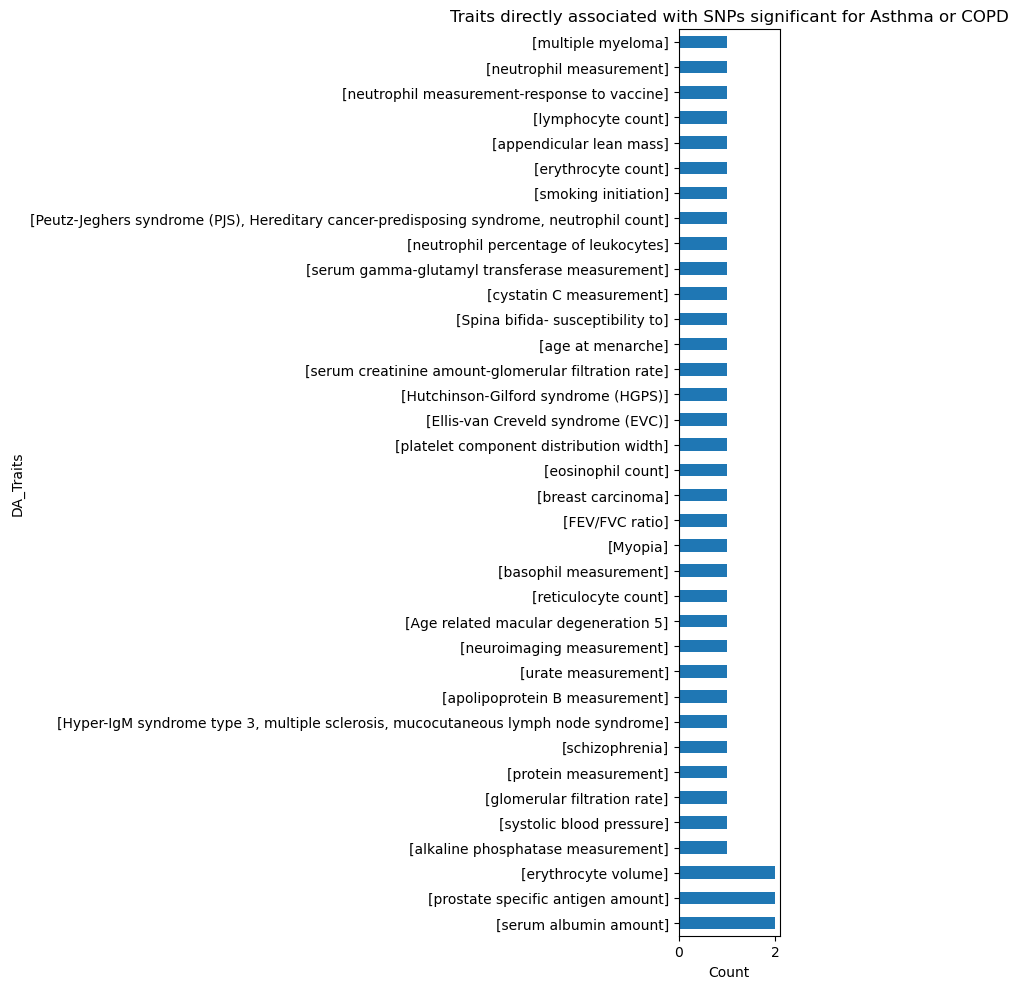

In [20]:


plt.figure(figsize=(8, 10))
#trait_counts.index = trait_counts.index.str.slice(0, 80) + "…"  # truncate to 40 chars
trait_counts.plot(kind="barh")  # horizontal bar plot
plt.xlabel("Count")
plt.ylabel("DA_Traits")
plt.title("Traits directly associated with SNPs significant for Asthma or COPD")
plt.tight_layout()
plt.show()

In [44]:
help(plt.savefig)

# cases where more than one
#more_than_one = ["serum albumin amount", "prostate specific antigen amount", "neutrophil measurement-response to water", "erythrocyte volume"]

Help on function savefig in module matplotlib.pyplot:

savefig(*args, **kwargs)
    Save the current figure.
    
    Call signature::
    
      savefig(fname, *, dpi='figure', format=None, metadata=None,
              bbox_inches=None, pad_inches=0.1,
              facecolor='auto', edgecolor='auto',
              backend=None, **kwargs
             )
    
    The available output formats depend on the backend being used.
    
    Parameters
    ----------
    fname : str or path-like or binary file-like
        A path, or a Python file-like object, or
        possibly some backend-dependent object such as
        `matplotlib.backends.backend_pdf.PdfPages`.
    
        If *format* is set, it determines the output format, and the file
        is saved as *fname*.  Note that *fname* is used verbatim, and there
        is no attempt to make the extension, if any, of *fname* match
        *format*, and no extension is appended.
    
        If *format* is not set, then the format is inf

In [47]:
df_sorted

,DA_Traits,DA_Variants,BP,OR_copd,OR_asthma,meta_p_weighted,Filtered_Traits,DA_Traits_Clean
11,Ellis-van Creveld syndrome (EVC),[04_5753797_G_A],5753797.0,1.1280,1.0460,0.000267,[Ellis-van Creveld syndrome (EVC)],Ellis-van Creveld syndrome (EVC)
8,alkaline phosphatase measurement,[12_52873837_G_A],52873837.0,0.9454,0.9756,0.001011,[alkaline phosphatase measurement],alkaline phosphatase measurement
289,serum creatinine amount-glomerular filtration ...,[15_45642671_C_A],45642671.0,1.0640,0.9838,0.004086,[serum creatinine amount-glomerular filtration...,serum creatinine amount-glomerular filtration ...
64,prostate specific antigen amount,[17_2396472_A_G],2396472.0,1.0370,1.0310,0.007429,[prostate specific antigen amount],prostate specific antigen amount
151,serum gamma-glutamyl transferase measurement,[12_52879136_A_G],52879136.0,0.9622,0.9772,0.007979,[serum gamma-glutamyl transferase measurement],serum gamma-glutamyl transferase measurement
122,smoking initiation,[19_55368504_C_T],55368504.0,0.9675,0.9772,0.010090,[smoking initiation],smoking initiation
40,lymphocyte count,[14_103561933_T_C],103561933.0,1.0260,1.0330,0.010833,[lymphocyte count],lymphocyte count
310,platelet component distribution width,[21_39314595_C_T],39314595.0,1.0520,1.0140,0.016009,[platelet component distribution width],platelet component distribution width
278,erythrocyte volume,[11_33892021_T_C],33892021.0,1.0410,0.9833,0.021207,[erythrocyte volume],erythrocyte volume
321,Age related macular degeneration 5,[10_49539493_G_C],49539493.0,0.9503,0.9867,0.021276,[Age related macular degeneration 5],Age related macular degeneration 5


/var/folders/dp/zmpkfc9n3yld16sv5nhc1x5c0000gn/T/ipykernel_63311/4021828601.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['DA_Traits_Clean'] = df_filtered['DA_Traits'].apply(lambda x: x[0] if isinstance(x, list) else x)


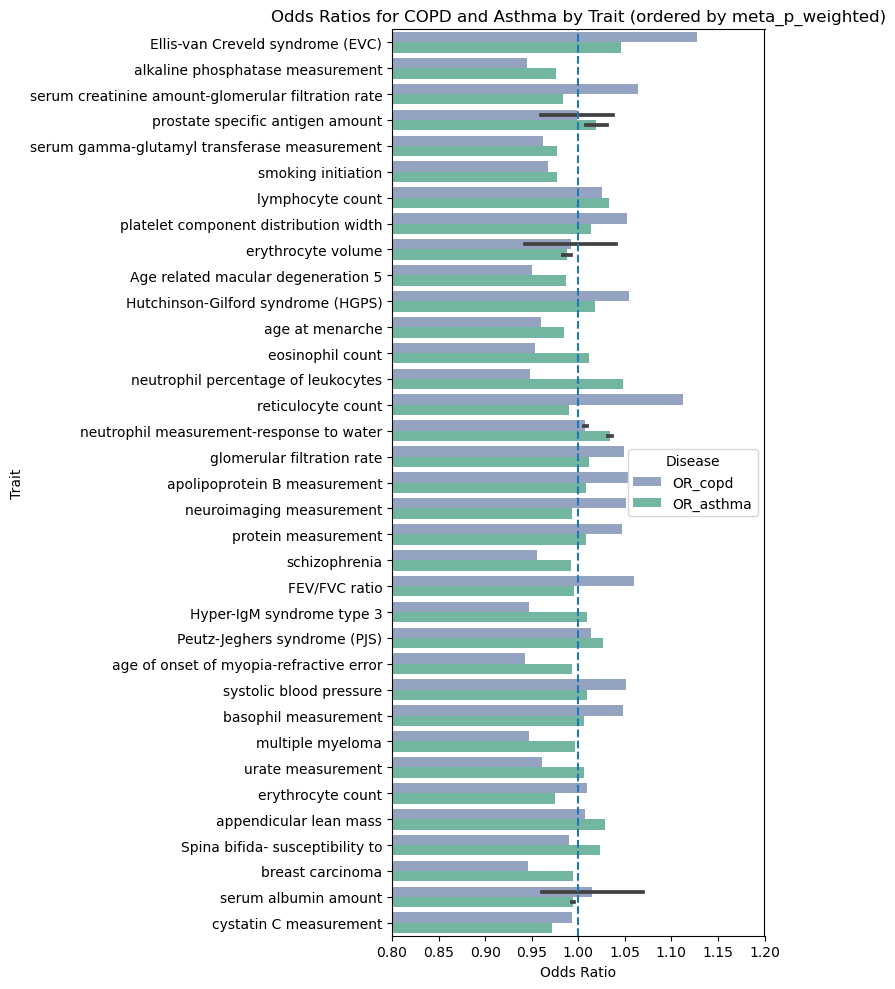

In [46]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_filtered['DA_Traits_Clean'] = df_filtered['DA_Traits'].apply(lambda x: x[0] if isinstance(x, list) else x)

# Sort by meta_p_weighted
df_sorted = df_filtered.sort_values("meta_p_weighted")
# if multiple then just consider the highest one

# Melt for plotting OR_copd vs OR_asthma
df_melted = df_sorted.melt(
    id_vars=["DA_Traits_Clean", "meta_p_weighted"],
    value_vars=["OR_copd", "OR_asthma"],
    var_name="Disease",
    value_name="OddsRatio"
)


# Plot
plt.figure(figsize=(8, 10))
sns.barplot(
    data=df_melted,
    x="OddsRatio", 
    y="DA_Traits_Clean", 
    hue="Disease", 
    palette = ["#8da0cb", "#66c2a5"],
    dodge=True,
    order=df_sorted["DA_Traits_Clean"].unique()
)
plt.axvline(x=1, linestyle="--")
plt.xlim(0.8, 1.2)
plt.title("Odds Ratios for COPD and Asthma by Trait (ordered by meta_p_weighted)")
plt.xlabel("Odds Ratio")
plt.ylabel("Trait")
plt.legend(title="Disease")
plt.tight_layout()
plt.savefig("./Odd_Ratio_COPD_Asthma.pdf", pad_inches=0.3, format="pdf")

plt.show()
